In [1]:
from pixelquad import *
from paint import *

In [34]:
root = pixel(np.array([[0,0],[0,1],[1,0],[1,1]]))
pq = pixelquad(root)


In [58]:
def equal_down_recursive(pq, rt = root, maxi = 3):
    if rt.level <= maxi:
        pq.down(rt)
        for s in rt.sons:
            in_out(s)
            print(s.color)
            if maxi - 1 >= 0:
                equal_down_recursive(pq, s, maxi = maxi - 1)

equal_down_recursive(pq,rt = root, maxi = 2)



blue
white
white
white
white
blue
white
blue
white
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue


white
white
white
blue
white
white
white
white
white
white
white
blue
white
blue
white
blue
white
blue
blue
blue
blue
blue
blue
blue
white
white
white
white
white
white
white
blue
white
blue
white
blue
white
blue
blue
blue
blue
blue
blue
blue
white
white
blue
blue
blue
white
white
white
white
white
red
white
blue
white
blue
white
white
red
red
white
white
white
white
white
blue
white
blue
blue
blue
blue
blue
blue
white
white
blue
white
blue
blue
blue
blue
blue
blue
white
blue
blue
blue
blue
blue
white
white
white
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
blue
white
white
blue
blue
blue
white
white
white
white
white
red
white
blue
white
blue
white
white
red
red
white
white
white
white
white
blue
white
blue
blue
blue
blue
blue
blue
white
white
blue
white
blue
blue
blue
blue
blue
blue
white
blue
blue
blue
blue
blue
white
white
white
blue
blue
blue
blue
blue
blue
blue
blue


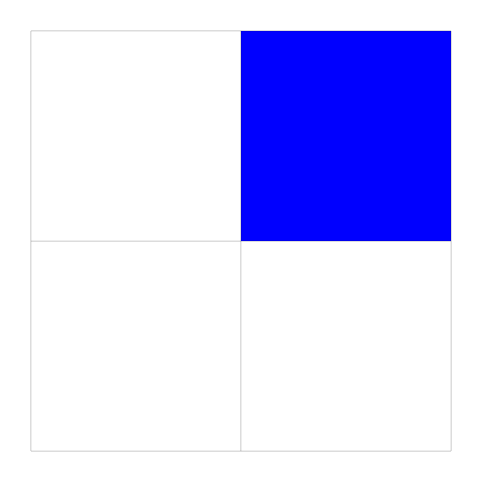

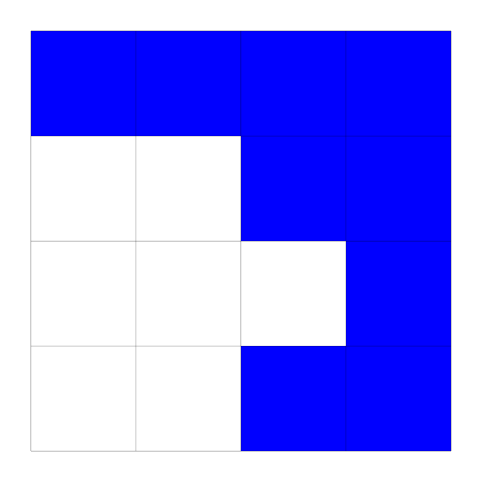

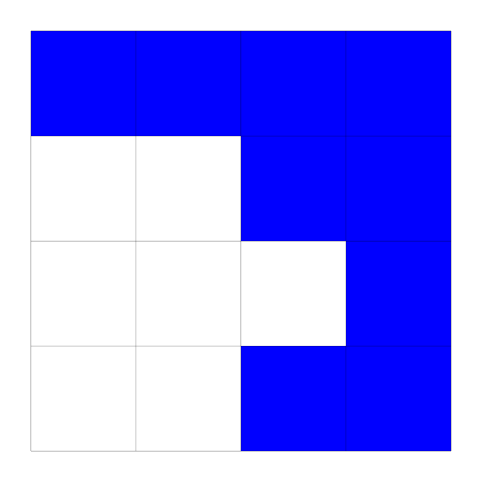

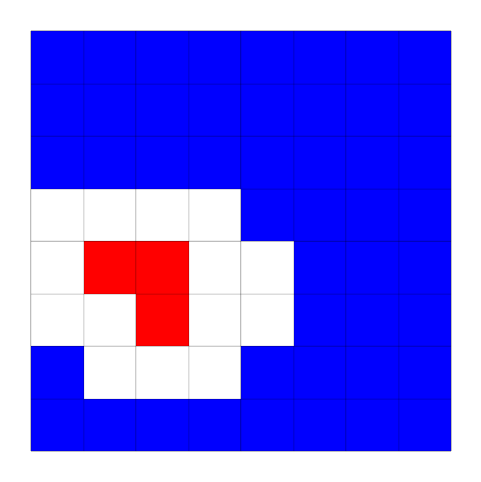

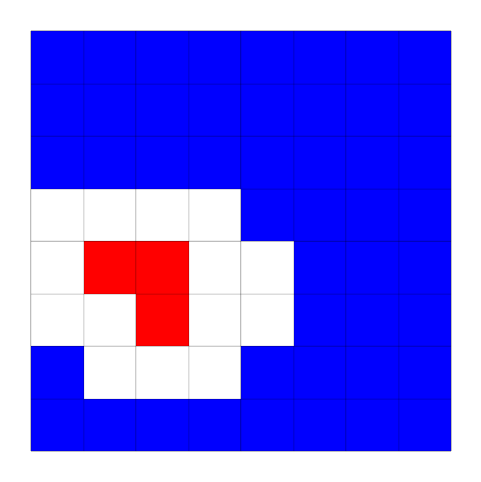

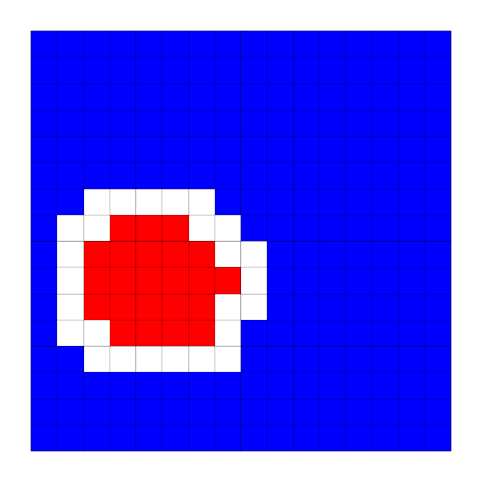

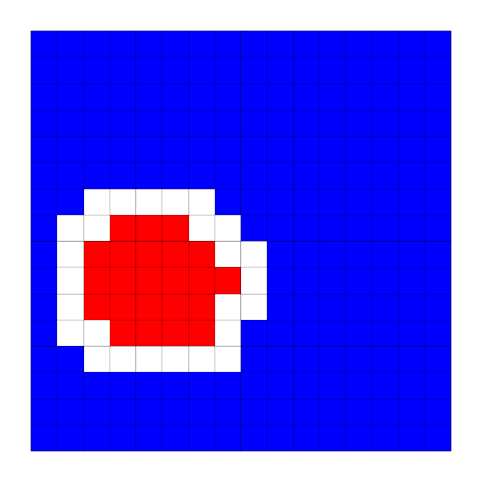

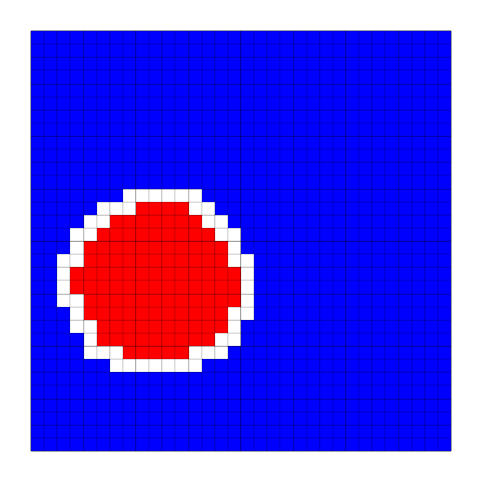

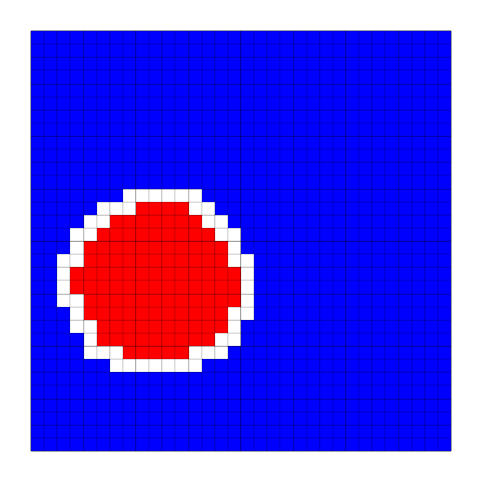

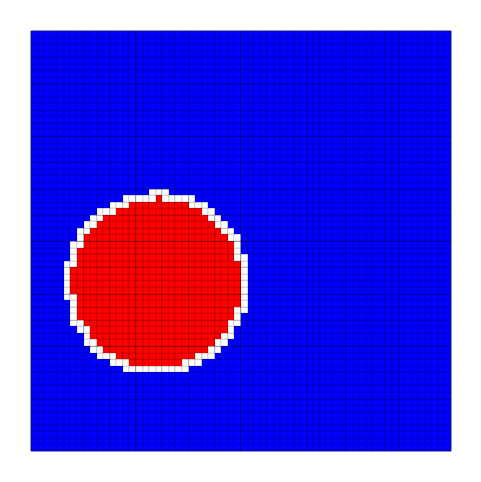

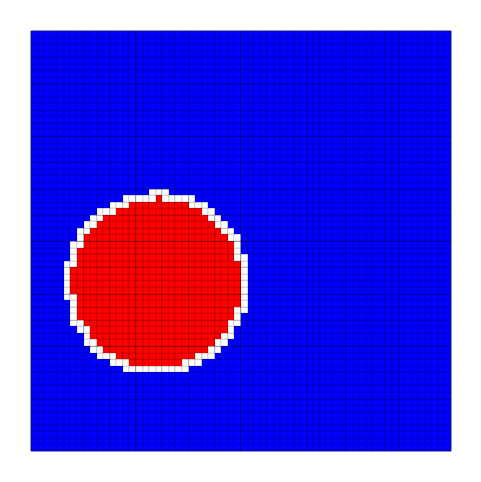

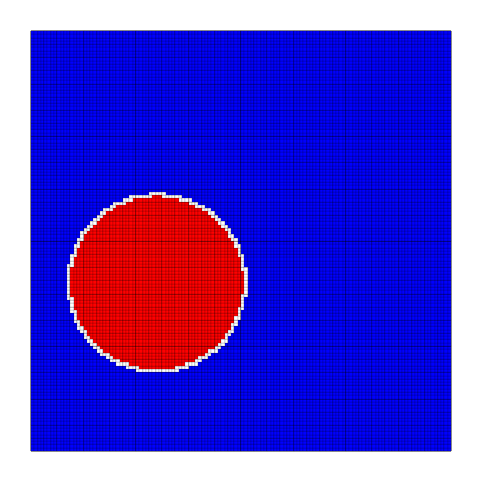

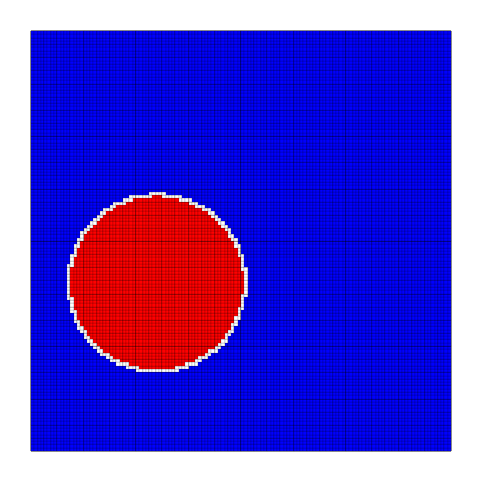

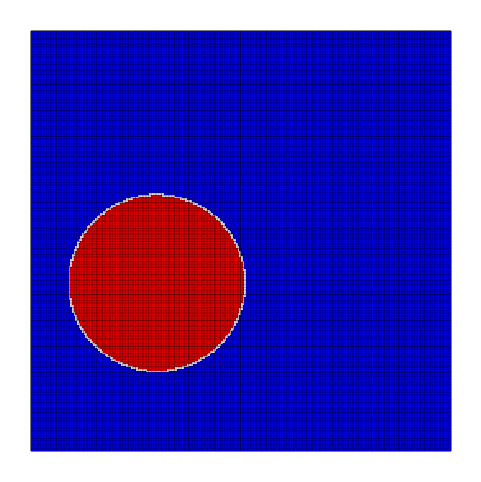

In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- FUNÇÃO DE PRINT COM MATPLOTLIB ---
def plot_current_tree(pq, patch):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    def draw_recursive(pxl):
        # Define a cor padrão caso pxl.color não exista ou seja outra
        cor_preenchimento = 'none'
        
        # Verifica o atributo color do pixel
        # Certifique-se de que sua classe pixel define self.color
        if hasattr(pxl, 'color'):
            if pxl.color == "red":
                cor_preenchimento = "red"
            elif pxl.color == "white":
                cor_preenchimento = "white"
            elif pxl.color == "blue":
                cor_preenchimento = "blue"
            
        # Pega as coordenadas (p1=inferior esquerdo, p4=superior direito)
        x_min, y_min = pxl.coordinates[0]
        x_max, y_max = pxl.coordinates[3]
        
        # Desenha o quadrado com facecolor definida
        rect = patches.Rectangle(
            (x_min, y_min), 
            x_max - x_min, 
            y_max - y_min, 
            linewidth=0.1, 
            edgecolor='black', 
            facecolor=cor_preenchimento
        )
        ax.add_patch(rect)
        
        # Se tiver filhos, desenha os filhos recursivamente
        for filho in pxl.sons:
            draw_recursive(filho)

    draw_recursive(pq.root)
    
    # Configurações do gráfico
    ax.set_aspect('equal')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.axis('off') # Remove os eixos para focar apenas na Quadtree
    plt.savefig(patch)

# Para testar, lembre-se de que os pixels precisam ter o atributo .color definido
# Exemplo: pq.root.color = "red"
for i in range(0,14):
    root = pixel(np.array([[0,0],[0,1],[1,0],[1,1]]))
    pq = pixelquad(root)
    equal_down_recursive(pq, rt = root, maxi = i+1)
    plot_current_tree(pq,f"arvore max = {i+1}")

In [48]:
import imageio
import os

def make_gif_from_pngs(
    image_dir="images",
    output="quadtree.gif",
    fps=1
):
    ordered_files = [
        "arvore max = 1.png",
        "arvore max = 2.png",
        "arvore max = 4.png",
        "arvore max = 6.png",
        "arvore max = 8.png",
        "arvore max = 10.png",
        "arvore max = 12.png",
    ]

    images = []

    for file in ordered_files:
        path = os.path.join(image_dir, file)
        images.append(imageio.imread(path))

    imageio.mimsave(output, images, fps=fps)


make_gif_from_pngs("images", "quadtree.gif", fps=1.5)



/tmp/ipykernel_18528/2101176079.py:23: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(path))


In [ ]:
import numpy as np


root = pixel(np.array([[0,0], [1,0], [0,1], [1,1]]))
pq = pixelquad(root)

def equal_down_recursive(pq, rt, maxi=5):

    in_out(rt) 
    

    if rt.color == "white" and rt.level < maxi:
        pq.down(rt) 
        
        for s in rt.sons:
    
            equal_down_recursive(pq, s, maxi)


equal_down_recursive(pq, root, maxi=5)

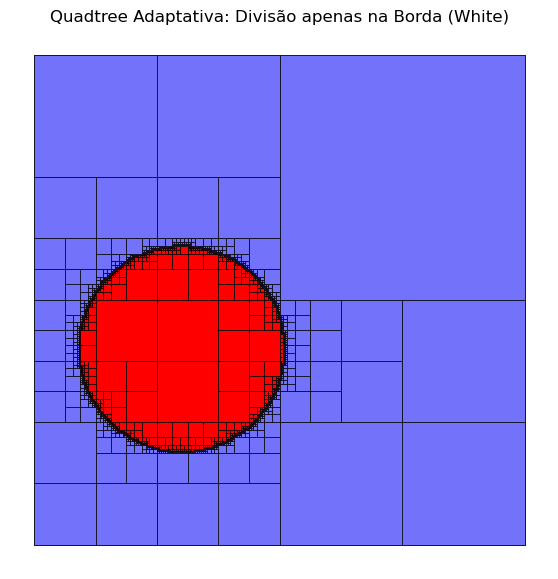

In [10]:
# --- 3. Função de Plotagem ---
def plot_current_tree(pq):
    fig, ax = plt.subplots(figsize=(7, 7))
    
    def draw_recursive(pxl):
        x_min, y_min = pxl.coordinates[0]
        x_max, y_max = pxl.coordinates[3]
        
        # Mapeamento de cores para visualização
        face = "none"
        if hasattr(pxl, 'color'):
            if pxl.color == "white": face = "#E2CDCD" # Cinza claro para borda
            elif pxl.color == "red": face = "#FF0000" # Vermelho claro para dentro
            elif pxl.color == "blue": face = "#7272FA" # Azul claro para fora
            
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                                 linewidth=0.5, edgecolor='black', facecolor=face)
        ax.add_patch(rect)
        
        for filho in pxl.sons:
            draw_recursive(filho)

    draw_recursive(pq.root)
    ax.set_aspect('equal')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.axis('off')
    plt.title("Quadtree Adaptativa: Divisão apenas na Borda (White)")
    plt.show()

# --- EXECUÇÃO ---
# Nível 6 permite ver bem o efeito adaptativo sem pesar
equal_down_recursive(pq, rt=root, maxi=10) 
plot_current_tree(pq)